# DS 207 Final Project — Elastic Net Regression (V1 vs V2)
**Team:** Greed and Fear  
**Author:** Vinit Bhatt  
**Date:** March 17, 2026  
**Revised:** March 26, 2026 — removed duplicate 5-day feature from model inputs

**Goal:** Predict next-week realized volatility for S&P 500 ETFs.  
**Target:** `forward_vol_5d_annual_decimel_calculated`

Two versions run back-to-back on identical rows, then compared:

| Version | Features | Purpose |
|---|---|---|
| V1 | Current-state volatility only (2 features) | Does the current volatility state predict future volatility? |
| V2 | V1 + current macro / market features (8 features) | Does current macro / market context improve V1? |

**Locked design choices for this notebook:**
- No lagged features are used in modeling.
- Lagged columns stay in the dataset, but are explicitly excluded from the model feature lists.
- `baseline_y_known_at_t` is added as a sixth baseline using `y_known_at_t` (naive current-volatility / persistence baseline).
- `trailing_vol_annual_decimel_5d_calculated` is intentionally excluded from modeling because it duplicates `y_known_at_t` row by row in this dataset.
- Both versions are trained and evaluated on the identical V2-complete row subset for a strict apples-to-apples comparison.
- Two baseline tables are produced: Table A on shared rows, Table B on full available test rows.

**Splits (per methodology doc 2026-03-07):**

| Split | Dates | Rows |
|---|---|---|
| Train | 2015-01-02 → 2022-12-30 | ~68,013 |
| Validation | 2023-01-03 → 2024-12-31 | 18,072 |
| Test | 2025-01-02 → 2025-12-31 | ~8,820 |

**Revision note:**  
This notebook keeps `y_known_at_t` as the single 5-day known-at-time volatility signal.  
It drops `trailing_vol_annual_decimel_5d_calculated` from model inputs because the two columns are duplicates in this dataset.


##Description of Code

This notebook builds and evaluates two Elastic Net regression models for the DATASCI 207 volatility final project using pre-split train, validation, and test datasets. Its goal is to predict forward_vol_5d_annual_decimel_calculated, which represents next-week realized volatility for the ETF universe.

Version 1 uses only current-state volatility inputs, specifically y_known_at_t and trailing_vol_annual_decimel_20d_calculated.

Version 2 adds current macro and market context variables: volume, NYGOLDS, OIL_WTI_S, US_10Y_BOND_YLD, US_3M_TB_YLD, and VIX.

The notebook also explicitly handles an important dataset issue: y_known_at_t and trailing_vol_annual_decimel_5d_calculated are duplicates row by row in this dataset, so the duplicate 5-day trailing-volatility column is excluded from model inputs and only y_known_at_t is retained. Lagged features remain in the dataset for reference but are intentionally excluded from modeling in this notebook.

The workflow mounts Google Drive, loads the train, validation, and test CSV files, validates required columns, confirms there is no date overlap across splits, verifies the duplicate-column issue, and creates a sixth baseline baseline_y_known_at_t without modifying the source CSV files. It then cleans the splits to ensure V1 and V2 are compared on the same shared test rows. For each model version, the notebook standardizes predictors using training data only, tunes Elastic Net hyperparameters (alpha and l1_ratio) with a fixed chronological train-to-validation fold, refits the final model on train plus validation, generates clipped nonnegative predictions, and reports MAE, RMSE, R², overfit gap, and which features were retained versus zeroed out by regularization.

In addition to the two Elastic Net models, the notebook compares results against six baselines: baseline_y_known_at_t, baseline_avg_5, baseline_avg_20, baseline_ols_5, baseline_ols_20, and baseline_xgb_walkforward. It produces baseline tables on shared test rows and full available test rows, side-by-side V1 versus V2 comparisons, feature inventories and coefficient tables, diagnostic plots, subgroup results for market, sector, and industry ETFs, and a final summary of the main findings.

## Cell 1 - Imports

**Purpose of this cell**

This cell imports the Python libraries needed for the notebook. These packages support data loading, numerical work, plotting, model fitting, feature scaling, and model evaluation.

**What this code is doing**

*   pandas is imported as pd so the notebook can load and manipulate tabular
datasets.
*   numpy is imported as np so the notebook can perform numerical operations and array handling.
*   matplotlib.pyplot is imported as plt so the notebook can create comparison plots and diagnostic charts.
*   ElasticNet and ElasticNetCV are imported from sklearn.linear_model so the notebook can fit the final Elastic Net model and tune its hyperparameters.
*   StandardScaler is imported from sklearn.preprocessing so model inputs can be standardized using training data only.
*   mean_absolute_error, mean_squared_error, and r2_score are imported from sklearn.metrics so the notebook can evaluate prediction accuracy on train, validation, and test data.
*   The final print("imports ok") line is a simple confirmation message showing that all imports ran successfully.

**Expected output**

If the cell runs correctly, the output should be:
*   imports ok

In [1]:
# Cell 1 - Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("imports ok")

imports ok


**Comment on Output for Cell 1 - Imports**

Cell ran correctly.

## Cell 2A - Mount Google Drive to load datasets

**Purpose of this cell**

This cell connects the Colab notebook to Google Drive so the notebook can access the train, validation, and test CSV files stored in Drive.

**What this code is doing**

*   from google.colab import drive imports the Google Drive interface used inside Colab.
*   drive.mount('/content/drive') mounts Google Drive to the Colab runtime at the folder path /content/drive.
*   Once Drive is mounted, the notebook can read files from locations such as:
/content/drive/MyDrive/Colab Notebooks/

This step is required because the model inputs are stored in Google Drive rather than directly inside the Colab session.

**Expected output**

If the cell runs correctly, the output should be:

*   Mounted at /content/drive

In [2]:
# Cell 2A - Mount Google Drive to load datasets

# Connect Google Drive to this Colab notebook
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


**Comment On Output for Cell 2A - Mount Google Drive to load datasets**

Cell ran correctly.

## Cell 2B - Load pre-split datasets

**Purpose of this cell**

This cell loads the pre-split train, validation, and test datasets from Google Drive, converts the date column into datetime format, creates a sixth baseline column if needed, and verifies that the three dataset splits do not overlap in time.

**What this code is doing**

*   The cell first defines the base Google Drive folder path where the CSV files are stored.
*   It then builds full file paths for the three pre-split datasets:
    *   vol_dataset_train_20150102_20221230.csv
    *   vol_dataset_validation_20230103_20241231.csv
    *   vol_dataset_test_20250102_20251231.csv
*   The helper function load_split(path, label):
    *   reads a CSV file into a pandas DataFrame,
    *   converts the date column to datetime format,
    *   creates baseline_y_known_at_t if that column is not already present by copying y_known_at_t,
    *   prints a summary showing the number of rows, date range, and number of unique tickers in that split.
*   The function is then used to load the train, validation, and test datasets into:
    *   train_raw
    *   val_raw
    *   test_raw
*   After loading, the code checks that the date ranges do not overlap:
    *   train ends before validation begins
    *   validation ends before test begins
*   Finally, it prints confirmation that the split boundaries are valid and that the sixth baseline was derived successfully.



**Expected output**

If the cell runs correctly, the output should be:
*   A table describing datasets for train, val and test.

In [3]:
# Cell 2B - Load pre-split datasets

# Dataset already split per methodology doc (2026-03-07).
# Update BASE to folder path in Colab:
#   from google.colab import drive
#   drive.mount('/content/drive')
#   BASE = "/content/drive/MyDrive/207_project/"

BASE = "/content/drive/MyDrive/Colab Notebooks/"

TRAIN_FILE = BASE + "vol_dataset_train_20150102_20221230.csv"
VAL_FILE   = BASE + "vol_dataset_validation_20230103_20241231.csv"
TEST_FILE  = BASE + "vol_dataset_test_20250102_20251231.csv"

def load_split(path, label):
    df = pd.read_csv(path, low_memory=False)
    df['date'] = pd.to_datetime(df['date'], format='mixed', errors='coerce')

    # Derive sixth baseline without editing the CSV files.
    if 'baseline_y_known_at_t' not in df.columns and 'y_known_at_t' in df.columns:
        df['baseline_y_known_at_t'] = df['y_known_at_t']

    print(f"{label}: {len(df):,} rows  |  {df['date'].min().date()} to {df['date'].max().date()}  |  {df['ticker'].nunique()} tickers")
    return df

train_raw = load_split(TRAIN_FILE, "train")
val_raw   = load_split(VAL_FILE,   "val  ")
test_raw  = load_split(TEST_FILE,  "test ")

assert train_raw['date'].max() < val_raw['date'].min(),  "train/val date overlap!"
assert val_raw['date'].max()   < test_raw['date'].min(), "val/test date overlap!"
print("no date overlap - good")
print("derived sixth baseline: baseline_y_known_at_t = y_known_at_t")


train: 69,422 rows  |  2015-01-02 to 2022-12-30  |  36 tickers
val  : 18,072 rows  |  2023-01-03 to 2024-12-31  |  36 tickers
test : 9,000 rows  |  2025-01-02 to 2025-12-31  |  36 tickers
no date overlap - good
derived sixth baseline: baseline_y_known_at_t = y_known_at_t


**Comment for Cell 2B Output**

Cell ran correctly:
*   train loaded correctly
*   validation loaded correctly
*   test loaded correctly
*   no date overlap exists across splits
*   the sixth baseline baseline_y_known_at_t was created correctly

## Cell 3 - Define feature sets, target, baselines, and duplicate-column handling

**Purpose of this cell**

This cell defines the modeling design for the notebook. It specifies the prediction target, builds the feature sets for Elastic Net Version 1 and Version 2, lists lagged features that are intentionally excluded, defines the six baselines used for comparison, and explicitly handles the duplicate-column issue in the dataset by keeping y_known_at_t and excluding trailing_vol_annual_decimel_5d_calculated from model inputs.

**What this code is doing**

*   It sets the prediction target to:
    *   forward_vol_5d_annual_decimel_calculated
*   It defines the current-state feature set used in V1:
    *   y_known_at_t
    *   trailing_vol_annual_decimel_20d_calculated
*   It explicitly documents the duplicate-column rule:
    *   keep y_known_at_t
    *   drop trailing_vol_annual_decimel_5d_calculated
    *   reason: the two columns are duplicates row by row in this dataset
*   It defines the current macro / market features added in V2:
    *   volume
    *   NYGOLDS
    *   OIL_WTI_S
    *   US_10Y_BOND_YLD
    *   US_3M_TB_YLD
    *   VIX
*   It defines the lagged features that remain in the dataset but are intentionally excluded from this notebook’s modeling design.
*   It builds:
    *   FEATURES_V1 = current-state features only
    *   FEATURES_V2 = current-state features + current macro/market features
*   It stores these in the VERSIONS dictionary so both models can be run in a consistent loop later in the notebook.
*   It defines the six baselines used for comparison:
    *   baseline_y_known_at_t
    *   baseline_avg_5
    *   baseline_avg_20
    *   baseline_ols_5
    *   baseline_ols_20
    *   baseline_xgb_walkforward
    *   It defines non-model columns that should never be passed into Elastic Net
    *   fitting, including:
    *   the target
    *   date
    *   ticker
    *   group_type
    *   all baseline columns
*   Finally, it prints a structured summary of the notebook design, including:
    *   the target
    *   the duplicate-handling rule
    *   the V1 feature list
    *   the V2 additional features
    *   the full V2 model input list
    *   the excluded lagged features
    *   the non-model columns
    *   the six baselines

**Expected output**

If the cell runs correctly, the output should:
*   Print a design summary including target, duplicate-handling rule, V1 features, V2 features, V2 model inputs, excluded lagged features and baselines.

In [4]:
# Cell 3 - Define feature sets, target, baselines, and duplicate-column handling

TARGET = 'forward_vol_5d_annual_decimel_calculated'

# -----------------------------
# Locked simple/current-state design
# -----------------------------
# V1 uses only the current-state volatility inputs.
# IMPORTANT:
# - Keep y_known_at_t as the single 5-day known-at-time volatility signal.
# - Drop trailing_vol_annual_decimel_5d_calculated from model inputs because
#   it duplicates y_known_at_t row by row in this dataset.
CURRENT_STATE_FEATURES = [
    'y_known_at_t',
    'trailing_vol_annual_decimel_20d_calculated',
]

# V2 adds current macro / market context (no lagged features).
CURRENT_MACRO_MARKET_FEATURES = [
    'volume',
    'NYGOLDS',
    'OIL_WTI_S',
    'US_10Y_BOND_YLD',
    'US_3M_TB_YLD',
    'VIX',
]

# Lagged columns remain in the dataset but are excluded from modeling.
# Note:
# - The 5-day lagged trailing-vol family also mirrors the y_known_at_t lagged family,
#   but all lagged features are excluded from this notebook by design.
LAGGED_FEATURES = [
    'y_known_at_t_lag1',
    'y_known_at_t_lag5',
    'y_known_at_t_lag20',
    'trailing_vol_annual_decimel_5d_calculated_lag1',
    'trailing_vol_annual_decimel_5d_calculated_lag5',
    'trailing_vol_annual_decimel_5d_calculated_lag20',
    'trailing_vol_annual_decimel_20d_calculated_lag1',
    'trailing_vol_annual_decimel_20d_calculated_lag5',
    'trailing_vol_annual_decimel_20d_calculated_lag20',
    'VIX_lag1',
    'VIX_lag5',
    'VIX_lag20',
]

FEATURES_V1 = CURRENT_STATE_FEATURES.copy()
FEATURES_V2 = CURRENT_STATE_FEATURES + CURRENT_MACRO_MARKET_FEATURES

VERSIONS = {
    'V1 (current-state vol)': FEATURES_V1,
    'V2 (current-state vol+macro)': FEATURES_V2,
}

# Six baselines: naive current-vol baseline + five existing baseline columns.
BASELINES = [
    'baseline_y_known_at_t',
    'baseline_avg_5',
    'baseline_avg_20',
    'baseline_ols_5',
    'baseline_ols_20',
    'baseline_xgb_walkforward',
]

NON_MODEL_COLUMNS = [
    TARGET,
    'date',
    'ticker',
    'group_type',
] + BASELINES

ALL_MODEL_CANDIDATES = sorted(set(FEATURES_V2))
EXCLUDED_BY_DESIGN = sorted(set(LAGGED_FEATURES))

print("Locked feature design for this notebook")
print("-" * 45)
print(f"Target: {TARGET}")
print("\nDuplicate-handling rule:")
print("  - Keep: y_known_at_t")
print("  - Drop from model inputs: trailing_vol_annual_decimel_5d_calculated")
print("  - Reason: the two columns are duplicates in this dataset")

print(f"\nV1 features ({len(FEATURES_V1)}):")
for f in FEATURES_V1:
    print(f"  - {f}")

print(f"\nV2 additional features ({len(CURRENT_MACRO_MARKET_FEATURES)}):")
for f in CURRENT_MACRO_MARKET_FEATURES:
    print(f"  - {f}")

print(f"\nV2 total model inputs ({len(FEATURES_V2)}):")
for f in FEATURES_V2:
    print(f"  - {f}")

print(f"\nExplicitly excluded lagged features ({len(EXCLUDED_BY_DESIGN)}):")
for f in EXCLUDED_BY_DESIGN:
    print(f"  - {f}")

print(f"\nNon-model columns excluded from fitting ({len(NON_MODEL_COLUMNS)}):")
for f in NON_MODEL_COLUMNS:
    print(f"  - {f}")

print(f"\nSix baselines used ({len(BASELINES)}):")
for f in BASELINES:
    print(f"  - {f}")


Locked feature design for this notebook
---------------------------------------------
Target: forward_vol_5d_annual_decimel_calculated

Duplicate-handling rule:
  - Keep: y_known_at_t
  - Drop from model inputs: trailing_vol_annual_decimel_5d_calculated
  - Reason: the two columns are duplicates in this dataset

V1 features (2):
  - y_known_at_t
  - trailing_vol_annual_decimel_20d_calculated

V2 additional features (6):
  - volume
  - NYGOLDS
  - OIL_WTI_S
  - US_10Y_BOND_YLD
  - US_3M_TB_YLD
  - VIX

V2 total model inputs (8):
  - y_known_at_t
  - trailing_vol_annual_decimel_20d_calculated
  - volume
  - NYGOLDS
  - OIL_WTI_S
  - US_10Y_BOND_YLD
  - US_3M_TB_YLD
  - VIX

Explicitly excluded lagged features (12):
  - VIX_lag1
  - VIX_lag20
  - VIX_lag5
  - trailing_vol_annual_decimel_20d_calculated_lag1
  - trailing_vol_annual_decimel_20d_calculated_lag20
  - trailing_vol_annual_decimel_20d_calculated_lag5
  - trailing_vol_annual_decimel_5d_calculated_lag1
  - trailing_vol_annual_decim

**Comment on Output for Cell 3 - Define feature sets, target, baselines, and duplicate-column handling**

Cell 3 output looks correct:
*   V1 features = 2
    *   y_known_at_t
    *   trailing_vol_annual_decimel_20d_calculated
*   V2 total model inputs = 8
    *   the 2 V1 features
    *   plus 6 macro/market features
*   trailing_vol_annual_decimel_5d_calculated is not in the model input list
*   lagged features are explicitly excluded
*   the six baselines are listed correctly

So this means the duplicate-column fix is set up correctly in the notebook.



## Cell 4 - Verify duplicate 5-day columns and validate required columns

**Purpose of this cell**

This cell performs two pre-modeling data validation checks.

First, it confirms that y_known_at_t and trailing_vol_annual_decimel_5d_calculated are exact duplicates in the train, validation, and test datasets.

Second, it verifies that all columns required for modeling and baseline comparison are present and that there are no duplicate (ticker, date) rows in any split.

**What this code is doing**
*   It defines a helper function, check_duplicate_pair(df, col_a, col_b, label), to compare two columns within a dataset.
*   For each split (train_raw, val_raw, and test_raw), the function:
    *   keeps only rows where both columns are non-missing,
    *   checks whether the two columns match exactly row by row,
    *   counts any mismatched rows,
    *   counts cases where one column is missing and the other is not.
*   The code applies that check to:
    *   y_known_at_t
    *   trailing_vol_annual_decimel_5d_calculated

This confirms whether the duplicate-column handling decision from Cell 3 is supported by the actual data.

*   The cell then builds a list of required columns using:
    *   the full V2 feature set,
    *   the target column,
    *   the six baseline columns,
    *   and the identifier columns date, ticker, and group_type
*   For each dataset split, it checks:
    *   whether any required columns are missing,
    *   whether any duplicate (ticker, date) rows exist.

Finally, it prints a summary of these checks so the notebook can confirm that the dataset structure is valid before moving into model cleaning and fitting.

**Expected output**

If the cell runs correctly, the output should:
*   Print description of split datasets.

In [5]:
# Cell 4 - Verify duplicate 5-day columns and validate required columns

def check_duplicate_pair(df, col_a, col_b, label):
    both_nonmissing = df[[col_a, col_b]].dropna()
    exact_match = (both_nonmissing[col_a] == both_nonmissing[col_b]).all()
    mismatch_count = (both_nonmissing[col_a] != both_nonmissing[col_b]).sum()
    one_missing_only = (df[col_a].isna() ^ df[col_b].isna()).sum()

    print(f"{label}")
    print(f"  rows with both non-missing: {len(both_nonmissing):,}")
    print(f"  exact match on both non-missing rows: {exact_match}")
    print(f"  mismatch count: {mismatch_count:,}")
    print(f"  one-missing-only count: {one_missing_only:,}")
    print()

print("Duplicate-column check: y_known_at_t vs trailing 5-day realized volatility")
print("-" * 75)
for label, df in [('train', train_raw), ('val', val_raw), ('test', test_raw)]:
    check_duplicate_pair(
        df,
        'y_known_at_t',
        'trailing_vol_annual_decimel_5d_calculated',
        label
    )

required = sorted(set(FEATURES_V2 + [TARGET] + BASELINES + ['date', 'ticker', 'group_type']))

print("Required-column validation")
print("-" * 75)
for label, df in [('train', train_raw), ('val', val_raw), ('test', test_raw)]:
    missing = [c for c in required if c not in df.columns]
    dupes = df.duplicated(subset=['ticker', 'date']).sum()
    print(f"{label}: missing={missing}  |  duplicate (ticker,date)={dupes}")

print("column check done")


Duplicate-column check: y_known_at_t vs trailing 5-day realized volatility
---------------------------------------------------------------------------
train
  rows with both non-missing: 69,273
  exact match on both non-missing rows: True
  mismatch count: 0
  one-missing-only count: 0

val
  rows with both non-missing: 18,072
  exact match on both non-missing rows: True
  mismatch count: 0
  one-missing-only count: 0

test
  rows with both non-missing: 9,000
  exact match on both non-missing rows: True
  mismatch count: 0
  one-missing-only count: 0

Required-column validation
---------------------------------------------------------------------------
train: missing=[]  |  duplicate (ticker,date)=0
val: missing=[]  |  duplicate (ticker,date)=0
test: missing=[]  |  duplicate (ticker,date)=0
column check done


**Comment on Output for Cell 4 - Verify duplicate 5-day columns and validate required columns**

This output confirms that y_known_at_t and trailing_vol_annual_decimel_5d_calculated are exact duplicates across the train, validation, and test splits wherever both are present, with zero mismatches and zero one-missing-only cases.

This validates the design choice to keep y_known_at_t and exclude trailing_vol_annual_decimel_5d_calculated from model inputs.

The output also shows that all required columns are present in every split and that there are no duplicate (ticker, date) rows, so the datasets are structurally clean and ready for modeling.


## Cell 5 - Clean splits and verify row counts

**Purpose of this cell**

This cell creates the cleaned working datasets used for modeling and checks how many rows remain after removing observations with missing values in the required model columns.

It also confirms whether the shared test rows used for the V1 versus V2 comparison are the same as the full test rows used for the baseline-only comparison.

**What this code is doing**
*   It defines drop_cols as:
    *   all V2 model input features, plus
    *   the target column

This is done because V2 uses the larger feature set, so dropping missing values on the V2 columns ensures that both V1 and V2 are evaluated on the exact same rows. That makes the V1 versus V2 comparison strictly apples-to-apples.

*   It then creates cleaned modeling DataFrames:
    *   train_df
    *   val_df
    *   test_df

Each of these is formed by dropping rows with missing values in any of the columns listed in drop_cols.

*   It also creates:
    *   test_full

This version drops rows only where the target is missing. It is used later for the baseline-only comparison table.

*   The cell prints the row counts before and after cleaning for:
    *   train
    *   validation
    *   test
    *   full test
*   Finally, it compares test_df and test_full:
    *   if they have the same number of rows, then the shared-row baseline table and the full-row baseline table will be identical,
    *   if they differ, then the two baseline tables will use different row sets and may produce different MAE values.

**Expected output**

If the cell runs correctly, the output should:
*   Print description of split datasets showing dropped rows.

In [6]:
# Cell 5 - Clean splits and verify row counts

# Drop on V2 features (superset) so both versions run on identical rows.
# This keeps V1 vs V2 strictly apples-to-apples.
# Lagged features are excluded from modeling by design, so they are not part of drop_cols.
# We also separately track full rows for the baseline-only table (Table B).
drop_cols = FEATURES_V2 + [TARGET]

train_df = train_raw.dropna(subset=drop_cols).copy()
val_df   = val_raw.dropna(subset=drop_cols).copy()
test_df  = test_raw.dropna(subset=drop_cols).copy()

# full test rows (drop target NaN only) — used in baseline Table B
test_full = test_raw.dropna(subset=[TARGET]).copy()

print(f"train:  {len(train_raw):,} -> {len(train_df):,}  ({len(train_raw)-len(train_df)} dropped)")
print(f"val:    {len(val_raw):,} -> {len(val_df):,}  ({len(val_raw)-len(val_df)} dropped)")
print(f"test:   {len(test_raw):,} -> {len(test_df):,}  ({len(test_raw)-len(test_df)} dropped)")
print(f"test_full (target-only dropna): {len(test_full):,} rows")

# flag if shared rows != full rows — affects baseline comparability
diff = len(test_full) - len(test_df)
if diff == 0:
    print("\nshared rows == full rows: baseline Table A and B will be identical")
    print("(Current-state V2 features introduce no extra NaNs beyond target-only filtering)")
else:
    print(f"\n{diff} rows in test_full not in test_df — baseline tables will differ")
    print("Table A (shared rows) and Table B (full rows) will show different baseline MAEs")


train:  69,422 -> 68,733  (689 dropped)
val:    18,072 -> 18,072  (0 dropped)
test:   9,000 -> 8,820  (180 dropped)
test_full (target-only dropna): 8,820 rows

shared rows == full rows: baseline Table A and B will be identical
(Current-state V2 features introduce no extra NaNs beyond target-only filtering)


**Comment on Output for Cell 5 - Clean splits and verify row counts**

This output shows that the notebook successfully created cleaned modeling copies of the train, validation, and test splits by dropping rows with missing values in the required V2 feature set plus the target.

The training set lost 689 rows, the validation set lost none, and the test set lost 180 rows.

Importantly, the cleaned shared test set and the full target-available test set are identical at 8,820 rows, which means the baseline Table A and Table B comparisons will be exactly the same in this run.

## Cell 6 - Helper functions

**Purpose of this cell**

This cell defines the helper functions used later to train, tune, evaluate, and summarize the Elastic Net models.

It does not yet run the full modeling loop for V1 and V2, but it sets up the reusable functions that perform the main regression workflow and compute evaluation metrics.

**What this code is doing**

This cell defines two helper functions:
1. get_metrics(y_true, y_pred, name)
This small helper function computes standard regression metrics for a set of predictions:
*   MAE using mean_absolute_error
*   RMSE using the square root of mean_squared_error
*   R2 using r2_score

It returns those values in a dictionary along with a name label. This makes it easy to collect and print consistent model evaluation results later in the notebook.

2. run_elastic_net(version_name, features, train_df, val_df, test_df, target)

This is the main modeling pipeline for one Elastic Net version. It performs the full workflow for either V1 or V2:
*   extracts the feature matrix and target vector for the train, validation, and test splits
*   standardizes the predictors using StandardScaler, fitting the scaler on the train data only
*   combines train and validation data into a chronological tuning set
tunes Elastic Net hyperparameters using ElasticNetCV
    *   tries multiple l1_ratio values
    *   searches over a grid of alpha values
    *   uses a fixed chronological validation fold rather than random cross-validation
*   refits a final Elastic Net model on the combined train + validation data using the best hyperparameters
*   generates predictions for:
    *   train
    *   train+validation
    *   test
*   clips predictions at zero so predicted volatility cannot go negative
*   computes train, train+validation, and test metrics using get_metrics
*   records which candidate features were:
    *   retained with nonzero coefficients
    *   zeroed out by regularization
*   prints a summary showing:
    *   best alpha
    *   best l1_ratio
    *   train / train+validation / test MAE
    *   test R²
    *   overfit gap
    *   number of retained features
    *   number of zeroed features
*   returns all key outputs in a dictionary so later cells can compare results, build tables, and make plots

At the end of the cell, the notebook prints:"helper functions defined."

**Expected output**

If the cell runs correctly, the output should:
*   "helper functions defined."

In [7]:
# Cell 6 - Helper functions

def get_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}


def run_elastic_net(version_name, features, train_df, val_df, test_df, target):
    """
    Full pipeline for one version:
      1. extract arrays from shared-row splits
      2. scale on train only
      3. tune alpha/l1_ratio using fixed val fold
      4. refit final model on train+val
      5. score on train, train+val, test
      6. record which candidate features were retained vs zeroed
    """
    print(f"\n{'='*55}")
    print(f"Running: {version_name}  ({len(features)} candidate features)")
    print('='*55)

    X_train = train_df[features].values;  y_train = train_df[target].values
    X_val   = val_df[features].values;    y_val   = val_df[target].values
    X_test  = test_df[features].values;   y_test  = test_df[target].values

    # scale on train only
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)

    # tune: single explicit chronological fold (train → val)
    n_train   = len(X_train_sc)
    X_tv      = np.vstack([X_train_sc, X_val_sc])
    y_tv      = np.concatenate([y_train, y_val])
    custom_cv = [(np.arange(n_train), np.arange(n_train, n_train + len(X_val_sc)))]

    tuner = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 1.0],
        alphas=np.logspace(-4, 0, 50),
        cv=custom_cv,
        fit_intercept=True,
        max_iter=20000,
        n_jobs=-1,
        random_state=42
    )
    tuner.fit(X_tv, y_tv)
    best_alpha    = tuner.alpha_
    best_l1_ratio = tuner.l1_ratio_
    print(f"  best alpha={best_alpha:.6f}  l1_ratio={best_l1_ratio:.2f}")

    # refit on train+val with fresh scaler
    trainval_df  = pd.concat([train_df, val_df])
    X_trainval   = trainval_df[features].values
    y_trainval   = trainval_df[target].values
    final_scaler = StandardScaler()
    X_tv_sc      = final_scaler.fit_transform(X_trainval)
    X_test_sc    = final_scaler.transform(X_test)
    X_train_sc2  = final_scaler.transform(X_train)

    final_model = ElasticNet(
        alpha=best_alpha, l1_ratio=best_l1_ratio,
        fit_intercept=True, max_iter=20000, random_state=42
    )
    final_model.fit(X_tv_sc, y_trainval)

    # predictions clipped: vol >= 0
    y_train_pred    = np.clip(final_model.predict(X_train_sc2), 0, None)
    y_trainval_pred = np.clip(final_model.predict(X_tv_sc),     0, None)
    y_test_pred     = np.clip(final_model.predict(X_test_sc),   0, None)

    m_train = get_metrics(y_train,    y_train_pred,    f'{version_name} train')
    m_tv    = get_metrics(y_trainval, y_trainval_pred, f'{version_name} train+val')
    m_test  = get_metrics(y_test,     y_test_pred,     f'{version_name} test')

    coef_pairs      = list(zip(features, final_model.coef_))
    kept_features   = [f for f, c in coef_pairs if c != 0]
    zeroed_features = [f for f, c in coef_pairs if c == 0]

    print(f"  train MAE={m_train['MAE']:.4f}  train+val={m_tv['MAE']:.4f}  test={m_test['MAE']:.4f}  R2={m_test['R2']:.4f}")
    print(f"  overfit gap: {m_test['MAE'] - m_train['MAE']:+.4f}")
    print(f"  features retained by Elastic Net: {len(kept_features)} / {len(features)}")
    print(f"  features zeroed by Elastic Net:   {len(zeroed_features)} / {len(features)}")

    return {
        'version': version_name,
        'features': features,
        'n_features': len(features),
        'best_alpha': best_alpha,
        'best_l1ratio': best_l1_ratio,
        'model': final_model,
        'y_test': y_test,
        'y_test_pred': y_test_pred,
        'y_train': y_train,
        'y_train_pred': y_train_pred,
        'y_trainval': y_trainval,
        'y_trainval_pred': y_trainval_pred,
        'm_train': m_train,
        'm_tv': m_tv,
        'm_test': m_test,
        'kept_features': kept_features,
        'zeroed_features': zeroed_features,
    }

print("helper functions defined")


helper functions defined


**Comment on Output for Cell 6 - Helper functions**

The Cell 6 output is correct and expected.

The message helper functions defined confirms that the notebook successfully created the reusable functions needed for the rest of the workflow.

No model metrics appear yet because this cell only defines the helper functions; the actual Elastic Net fitting, tuning, prediction, and evaluation begin in the next cell.

## Cell 7 - Run both versions

**Purpose of this cell**

This cell runs the full Elastic Net modeling pipeline for both model versions defined earlier in the notebook. It trains, tunes, evaluates, and summarizes Version 1 and Version 2 using the cleaned train, validation, and test datasets, and stores the results for later comparison tables and plots.

**What this code is doing**

*  It creates an empty dictionary called all_results to store the outputs for each model version.
*  It loops through the VERSIONS dictionary created in Cell 3:
    *  V1 (current-state vol)
    *  V2 (current-state vol+macro)
*  For each version, it calls the helper function run_elastic_net(...) from Cell 6, passing:
    *  the version name
    *  the feature list for that version
    *  the cleaned train, validation, and test DataFrames
    *  the target column name
*  Inside that helper function, the notebook:
    *  extracts model inputs and targets,
    *  standardizes predictors using train-only scaling,
    *  tunes alpha and l1_ratio using a fixed chronological validation fold,
    *  refits the final model on train + validation,
    *  evaluates performance on train and test,
    *  and records which features were retained versus zeroed out.
*  The result for each version is saved into all_results so later cells can build *side-by-side comparisons, feature tables, plots, and final summaries.
*  After both versions finish, the cell prints:
    *  both versions complete

**Expected output**

If the cell runs correctly, it should:
*   print one modeling summary for V1 and one for V2, followed by a completion message.

In [8]:
# Cell 7 - Run both versions

all_results = {}

for version_name, features in VERSIONS.items():
    all_results[version_name] = run_elastic_net(
        version_name, features, train_df, val_df, test_df, TARGET
    )

print("\nboth versions complete")


Running: V1 (current-state vol)  (2 candidate features)
  best alpha=0.019307  l1_ratio=0.95
  train MAE=0.0802  train+val=0.0771  test=0.0855  R2=0.1794
  overfit gap: +0.0053
  features retained by Elastic Net: 2 / 2
  features zeroed by Elastic Net:   0 / 2

Running: V2 (current-state vol+macro)  (8 candidate features)
  best alpha=0.013257  l1_ratio=0.90
  train MAE=0.0777  train+val=0.0750  test=0.0846  R2=0.2188
  overfit gap: +0.0069
  features retained by Elastic Net: 3 / 8
  features zeroed by Elastic Net:   5 / 8

both versions complete


**Comment on Output for Cell 7 - Run both versions**

The output shows that both Elastic Net versions ran successfully and produced stable results.

V2 outperformed V1 on the test set, with lower MAE and higher R², indicating that the added current macro / market features contributed useful predictive information.

However, the improvement was modest, and V2 showed a slightly larger overfit gap than V1.

Elastic Net retained all 2 features in V1, but only 3 of 8 candidate features in V2, showing that regularization removed most of the added macro variables.

## Cell 8 - Table A: baselines on shared rows (same as V1/V2 test set)
**Purpose of this cell**

This cell evaluates the six baseline prediction methods on the exact same cleaned test rows used for the V1 versus V2 Elastic Net comparison.

Its purpose is to produce a fair apples-to-apples baseline table so the Elastic Net models can be compared directly against the baselines on the same row set.

**What this code is doing**

*   It creates an empty list called baseline_shared to store baseline evaluation
results.
*   It loops through the six baseline columns defined earlier in the notebook:
    *   baseline_y_known_at_t
    *   baseline_avg_5
    *   baseline_avg_20
    *   baseline_ols_5
    *   baseline_ols_20
    *   baseline_xgb_walkforward
*   For each baseline column:
    *   it pulls the baseline predictions from test_df,
    *   keeps only rows where that baseline prediction is not missing,
    *   compares those baseline predictions to the true test target values on the same rows,
    *   computes evaluation metrics using get_metrics(...), including MAE, RMSE, and R²,
    *   appends the result to baseline_shared.
*   The cell then prints Table A, showing the baseline name and its metrics on the shared test rows.
*   Finally, it identifies the best baseline in Table A by choosing the one with the lowest MAE and prints that result.

Because this table uses test_df, it is based on the same cleaned test rows used for the Elastic Net V1 and V2 models, which makes the comparison fair.

**Expected output**

If the cell runs correctly, it should:
*   print a baseline comparison table.

In [9]:
# Cell 8 - Table A: baselines on shared rows (same as V1/V2 test set)

# Table A uses the exact same rows as V1 and V2 — strictly apples-to-apples
baseline_shared = []
for col in BASELINES:
    b    = test_df[col].values
    keep = ~np.isnan(b)
    baseline_shared.append(get_metrics(test_df[TARGET].values[keep], b[keep], col))

print("Table A — six baselines on shared rows (current-state V2-complete subset)")
print(f"  rows: {len(test_df):,}")
print(f"\n{'Baseline':<35} {'MAE':>8} {'RMSE':>8} {'R2':>7}")
print('-' * 62)
for r in baseline_shared:
    print(f"{r['name']:<35} {r['MAE']:>8.4f} {r['RMSE']:>8.4f} {r['R2']:>7.4f}")

best_bl_shared = min(baseline_shared, key=lambda x: x['MAE'])
print(f"\nbest (shared): {best_bl_shared['name']}  MAE={best_bl_shared['MAE']:.4f}")


Table A — six baselines on shared rows (current-state V2-complete subset)
  rows: 8,820

Baseline                                 MAE     RMSE      R2
--------------------------------------------------------------
baseline_y_known_at_t                 0.1020   0.1619 -0.1680
baseline_avg_5                        0.1005   0.1625 -0.1773
baseline_avg_20                       0.0922   0.1491  0.0088
baseline_ols_5                        0.1644   0.2478 -1.7383
baseline_ols_20                       0.1298   0.2091 -0.9498
baseline_xgb_walkforward              0.0823   0.1352  0.1856

best (shared): baseline_xgb_walkforward  MAE=0.0823


**Comment on Output for Cell 8 - Table A: baselines on shared rows (same as V1/V2 test set)**

This output shows the baseline performance on the exact same shared test rows used for the V1 and V2 Elastic Net comparison.

The strongest baseline is baseline_xgb_walkforward, which achieves the lowest MAE and RMSE on this row set and therefore serves as the main benchmark to beat.

Among the simpler baseline methods, baseline_avg_20 performs best, while the OLS baselines perform poorly, especially baseline_ols_5.

## Cell 9 - Table B: baselines on full test rows

**Purpose of this cell**

This cell evaluates the six baseline prediction methods on the full available test set after dropping only rows where the target is missing.

Its purpose is to create a baseline table that can be compared against the original baseline document numbers and to check whether the baseline results change when using full test rows instead of the shared V1/V2 comparison rows.

**What this code is doing**
*   It creates an empty list called baseline_full to store the baseline evaluation results.
*   It loops through the six baseline columns defined earlier in the notebook:
    *   baseline_y_known_at_t
    *   baseline_avg_5
    *   baseline_avg_20
    *   baseline_ols_5
    *   baseline_ols_20
    *   baseline_xgb_walkforward
*   For each baseline column:
    *   it pulls the baseline predictions from test_full,
    *   keeps only rows where that baseline prediction is not missing,
    *   compares those predictions to the true target values on the same rows,
    *   computes MAE, RMSE, and R² using get_metrics(...),
    *   appends the result to baseline_full.
*   The cell then prints Table B, which shows baseline performance on the full target-available test rows.
*   Next, it finds the best baseline in Table B by selecting the one with the lowest MAE and prints that result.
*   Finally, it compares Table B MAE values against the earlier Table A MAE values:
    *   if the difference is essentially zero, it prints same
    *   otherwise, it flags that the baseline MAEs differ across the two row sets

This allows the notebook to verify whether the shared-row baseline comparison and the full-row baseline comparison are identical or different in this run.

**Expected output**

If the cell runs correctly, it should:
*   print a baseline comparison table with MAE, RMSE, R2.

In [10]:
# Cell 9 - Table B: baselines on full test rows

# Table B uses all available test rows (drop target NaN only).
# Allows cross-check against original baseline document numbers.
baseline_full = []
for col in BASELINES:
    b    = test_full[col].values
    keep = ~np.isnan(b)
    baseline_full.append(get_metrics(test_full[TARGET].values[keep], b[keep], col))

print("Table B — six baselines on full test rows (target-only dropna)")
print(f"  rows: {len(test_full):,}")
print(f"\n{'Baseline':<35} {'MAE':>8} {'RMSE':>8} {'R2':>7}")
print('-' * 62)
for r in baseline_full:
    print(f"{r['name']:<35} {r['MAE']:>8.4f} {r['RMSE']:>8.4f} {r['R2']:>7.4f}")

best_bl_full = min(baseline_full, key=lambda x: x['MAE'])
print(f"\nbest (full): {best_bl_full['name']}  MAE={best_bl_full['MAE']:.4f}")

# flag any differences
print("\nDifference check (Table B MAE - Table A MAE):")
for a, b_ in zip(baseline_shared, baseline_full):
    diff = b_['MAE'] - a['MAE']
    flag = '  <- differs' if abs(diff) > 0.0001 else '  same'
    print(f"  {a['name']:<35} {diff:+.6f}{flag}")


Table B — six baselines on full test rows (target-only dropna)
  rows: 8,820

Baseline                                 MAE     RMSE      R2
--------------------------------------------------------------
baseline_y_known_at_t                 0.1020   0.1619 -0.1680
baseline_avg_5                        0.1005   0.1625 -0.1773
baseline_avg_20                       0.0922   0.1491  0.0088
baseline_ols_5                        0.1644   0.2478 -1.7383
baseline_ols_20                       0.1298   0.2091 -0.9498
baseline_xgb_walkforward              0.0823   0.1352  0.1856

best (full): baseline_xgb_walkforward  MAE=0.0823

Difference check (Table B MAE - Table A MAE):
  baseline_y_known_at_t               +0.000000  same
  baseline_avg_5                      +0.000000  same
  baseline_avg_20                     +0.000000  same
  baseline_ols_5                      +0.000000  same
  baseline_ols_20                     +0.000000  same
  baseline_xgb_walkforward            +0.000000  same


**Comment on Output for Cell 9 - Table B: baselines on full test rows**

This output shows that the six baselines were successfully evaluated on the full target-available test set, and the strongest baseline remains baseline_xgb_walkforward.

The difference check confirms that every Table B MAE is identical to the corresponding Table A MAE, which means the shared-row and full-row test sets are the same in this run.

As a result, the baseline benchmark is fully consistent across both comparison tables.



## Cell 10 - Side-by-side comparison: V1 vs V2

**Purpose of this cell**
This cell creates a direct side-by-side comparison of Elastic Net Version 1 and Version 2 on the same shared test rows. Its purpose is to show whether adding current macro and market features improves performance over the simpler current-state-only model, and to show how close each Elastic Net version comes to the best baseline.

**What this code is doing**

*   It prints a title indicating that the comparison is between:
    *   V1 (current-state vol)
    *   V2 (current-state vol+macro) on the 2025 test set using identical shared rows.
*   It extracts the stored modeling results for:
    *   v1 = all_results['V1 (current-state vol)']
    *   v2 = all_results['V2 (current-state vol+macro)']
*   It defines a helper function delta_str(...) that computes the difference between V2 and V1 for each metric and labels whether that change is better or worse.
    *   For error metrics like MAE and RMSE, lower is better.
    *   For R², higher is better.
*   It then builds a comparison table for:
    *   test MAE
    *   test RMSE
    *   test R²
    *   train MAE
    *   overfit gap
    *   best alpha
    *   best l1_ratio
*   It also prints feature-count comparisons, including:
    *   total candidate features
    *   retained features
    *   zeroed features
*   Finally, it compares each Elastic Net version’s test MAE against the best baseline from Table A (best_bl_shared) and prints whether each version beats or trails that baseline.

This cell is the main summary comparison between the two Elastic Net model designs.

**Expected output**

If the cell runs correctly, it should:
*   print a comparison table of ELASTIC NET: V1 (current-state vol) vs V2 (current-state vol+macro).

In [11]:
# Cell 10 - Side-by-side comparison: V1 vs V2

print("\n" + "="*75)
print("ELASTIC NET: V1 (current-state vol) vs V2 (current-state vol+macro) — Test Set 2025")
print("(both evaluated on identical shared rows)")
print("="*75)

v1 = all_results['V1 (current-state vol)']
v2 = all_results['V2 (current-state vol+macro)']

def delta_str(v1_val, v2_val, lower_is_better=True):
    d = v2_val - v1_val
    if lower_is_better:
        tag = '▼ better' if d < 0 else ('▲ worse' if d > 0 else '=')
    else:
        tag = '▲ better' if d > 0 else ('▼ worse' if d < 0 else '=')
    return f"{d:+.4f}  {tag}"

print(f"\n{'Metric':<28} {'V1 (current-state)':>18} {'V2 (current+macro)':>18} {'Delta (V2-V1)':>20}")
print('-' * 90)

rows = [
    ("Test MAE",       v1['m_test']['MAE'],  v2['m_test']['MAE'],  True),
    ("Test RMSE",      v1['m_test']['RMSE'], v2['m_test']['RMSE'], True),
    ("Test R2",        v1['m_test']['R2'],   v2['m_test']['R2'],   False),
    ("Train MAE",      v1['m_train']['MAE'], v2['m_train']['MAE'], True),
    ("Overfit gap",    v1['m_test']['MAE']-v1['m_train']['MAE'],
                       v2['m_test']['MAE']-v2['m_train']['MAE'],   True),
    ("Best alpha",     v1['best_alpha'],     v2['best_alpha'],     True),
    ("Best l1_ratio",  v1['best_l1ratio'],   v2['best_l1ratio'],   None),
]

for label, val1, val2, lib in rows:
    ds = delta_str(val1, val2, lib) if lib is not None else f"{val2-val1:+.4f}"
    print(f"{label:<28} {val1:>18.4f} {val2:>18.4f} {ds:>20}")

print(f"{'Features total':<28} {v1['n_features']:>18d} {v2['n_features']:>18d} {v2['n_features']-v1['n_features']:>+20d}")
print(f"{'Features retained':<28} {len(v1['kept_features']):>18d} {len(v2['kept_features']):>18d}")
print(f"{'Features zeroed':<28} {len(v1['zeroed_features']):>18d} {len(v2['zeroed_features']):>18d}")

print("\n" + "="*75)

# vs best baseline (shared rows)
print(f"\nvs best baseline on shared rows: {best_bl_shared['name']}  MAE={best_bl_shared['MAE']:.4f}")
print(f"{'Model':<34} {'Test MAE':>10}  {'vs baseline':>12}")
print('-' * 60)
for name, res in all_results.items():
    gap = res['m_test']['MAE'] - best_bl_shared['MAE']
    direction = 'beats' if gap < 0 else 'behind'
    print(f"{name:<34} {res['m_test']['MAE']:>10.4f}  {gap:>+8.4f}  {direction}")



ELASTIC NET: V1 (current-state vol) vs V2 (current-state vol+macro) — Test Set 2025
(both evaluated on identical shared rows)

Metric                       V1 (current-state) V2 (current+macro)        Delta (V2-V1)
------------------------------------------------------------------------------------------
Test MAE                                 0.0855             0.0846    -0.0008  ▼ better
Test RMSE                                0.1357             0.1324    -0.0033  ▼ better
Test R2                                  0.1794             0.2188    +0.0394  ▲ better
Train MAE                                0.0802             0.0777    -0.0025  ▼ better
Overfit gap                              0.0053             0.0069     +0.0016  ▲ worse
Best alpha                               0.0193             0.0133    -0.0060  ▼ better
Best l1_ratio                            0.9500             0.9000              -0.0500
Features total                                2                  8           

**Comment on Output for Cell 10 - Side-by-side comparison: V1 vs V2**

This output shows that V2 improves on V1 across all major test metrics, with lower MAE, lower RMSE, and higher R² on the shared 2025 test rows.

The improvement is modest, and V2 shows a slightly larger overfit gap, but the increase in overfitting is small.

Elastic Net also performs meaningful feature selection in V2, retaining only 3 of 8 candidate inputs.

However, both Elastic Net versions still remain behind the strongest baseline, baseline_xgb_walkforward, on MAE.



## Cell 11 - Feature inventory and coefficients for both versions

**Purpose of this cell**

This cell documents exactly which features were available to the Elastic Net models, which features were intentionally excluded by design, and which candidate inputs were ultimately retained or zeroed out by regularization in Version 1 and Version 2.

It also prints the fitted coefficients so the final models can be interpreted in a transparent way.

**What this code is doing**

*   It begins by printing a feature inventory for the notebook, including:
    *   all model candidate features used by at least one version,
    *   the lagged features that remain in the dataset but are excluded by design,
    *   the non-model columns that are never passed into fitting.
*   It then loops through the stored results in all_results for:
    *   V1 (current-state vol)
    *   V2 (current-state vol+macro)
*   For each version, it:
    *   builds a small coefficient table from the fitted model,
    *   sorts the features by the absolute size of the coefficient,
    *   prints the list of candidate inputs provided to that model,
    *   prints which features were retained by Elastic Net (nonzero coefficients),
    *   prints which features were zeroed out by Elastic Net (coefficients shrunk to zero),
    *   prints the final coefficient table for that version.
*   At the end, it performs a focused check for V2 macro / market features only, showing which of the added macro variables survived regularization and which were zeroed out.

This cell is important because it connects the numerical performance results to the actual final model specification.


**Expected output**

If the cell runs correctly, it should:
*   print a table with feature inventory and coefficients.

In [12]:
# Cell 11 - Feature inventory and coefficients for both versions

print("\n" + "="*80)
print("FEATURE INVENTORY")
print("="*80)
print("Features used by design (passed to at least one model):")
for f in ALL_MODEL_CANDIDATES:
    print(f"  - {f}")

print("\nLagged features excluded by design (remain in dataset, not used in modeling):")
for f in EXCLUDED_BY_DESIGN:
    print(f"  - {f}")

print("\nNon-model columns excluded from fitting:")
for f in NON_MODEL_COLUMNS:
    print(f"  - {f}")

for name, res in all_results.items():
    coef_df = pd.DataFrame({
        'feature': res['features'],
        'coef': res['model'].coef_
    }).sort_values('coef', key=abs, ascending=False)

    kept   = res['kept_features']
    zeroed = res['zeroed_features']

    print(f"\n--- {name} ---")
    print(f"Candidate inputs provided to model ({res['n_features']}):")
    for f in res['features']:
        print(f"  - {f}")

    print(f"\nRetained by Elastic Net ({len(kept)}):")
    if kept:
        for f in kept:
            print(f"  - {f}")
    else:
        print("  - none")

    print(f"\nZeroed out by Elastic Net ({len(zeroed)}):")
    if zeroed:
        for f in zeroed:
            print(f"  - {f}")
    else:
        print("  - none")

    print(f"\n{'Feature':<55} {'Coef':>10}")
    print('-' * 67)
    for _, row in coef_df.iterrows():
        note = '  <- zeroed' if row['coef'] == 0 else ''
        print(f"{row['feature']:<55} {row['coef']:>10.6f}{note}")

# V2: which current macro / market features survived?
print("\n--- V2 current macro / market features retained? ---")
coef_lookup = dict(zip(FEATURES_V2, all_results['V2 (current-state vol+macro)']['model'].coef_))
for f in CURRENT_MACRO_MARKET_FEATURES:
    c    = coef_lookup[f]
    note = 'ZEROED' if c == 0 else f'kept   coef={c:+.6f}'
    print(f"  {f:<40} {note}")



FEATURE INVENTORY
Features used by design (passed to at least one model):
  - NYGOLDS
  - OIL_WTI_S
  - US_10Y_BOND_YLD
  - US_3M_TB_YLD
  - VIX
  - trailing_vol_annual_decimel_20d_calculated
  - volume
  - y_known_at_t

Lagged features excluded by design (remain in dataset, not used in modeling):
  - VIX_lag1
  - VIX_lag20
  - VIX_lag5
  - trailing_vol_annual_decimel_20d_calculated_lag1
  - trailing_vol_annual_decimel_20d_calculated_lag20
  - trailing_vol_annual_decimel_20d_calculated_lag5
  - trailing_vol_annual_decimel_5d_calculated_lag1
  - trailing_vol_annual_decimel_5d_calculated_lag20
  - trailing_vol_annual_decimel_5d_calculated_lag5
  - y_known_at_t_lag1
  - y_known_at_t_lag20
  - y_known_at_t_lag5

Non-model columns excluded from fitting:
  - forward_vol_5d_annual_decimel_calculated
  - date
  - ticker
  - group_type
  - baseline_y_known_at_t
  - baseline_avg_5
  - baseline_avg_20
  - baseline_ols_5
  - baseline_ols_20
  - baseline_xgb_walkforward

--- V1 (current-state vol)

**Comment on Output for Cell 11 - Feature inventory and coefficients for both versions**

This output shows that V1 keeps both of its current-state volatility features, while V2 starts with 8 candidate inputs but retains only 3 after Elastic Net regularization.

The only added macro / market feature that survives in V2 is VIX; the other 5 added macro variables are shrunk to zero.

This means the improvement from V2 is driven mainly by the original volatility-state features plus a modest incremental contribution from VIX.

## Cell 12 - Plots: V1 vs V2

**Purpose of this cell**

This cell creates a visual comparison of Elastic Net Version 1 and Version 2 on the 2025 test set.

Its purpose is to show model fit, feature importance, and baseline comparison in one figure so the relative strengths and weaknesses of the two model versions can be seen more clearly than from tables alone.

**What this code is doing**

*   It creates a 2-by-3 plotting layout using matplotlib, with:
    *   the top row for V1
    *   the bottom row for V2
*   It adds a figure title summarizing that the plots compare:
    *   V1 (current-state vol)
    *   V2 (current-state vol+macro)
on the 2025 test set.
*   For each model version stored in all_results, the code builds three plots:

**Column 1 — Predicted vs Actual scatter plot**

*   Uses the true test target values on the x-axis and model predictions on the y-axis.
*   Draws a red dashed 45-degree line representing perfect prediction.
*   Adds a small label showing that version’s test MAE and test R².
*   This plot shows how closely predictions align with the actual volatility values.

**Column 2 — Top coefficients bar chart**

*   Builds a coefficient table from the fitted Elastic Net model.
Sorts coefficients by absolute size.
*   Plots the largest nonzero coefficients as horizontal bars.
*   Positive coefficients are shown in blue and negative coefficients would be shown in red.
*   This plot reveals which features matter most in each model version.

**Column 3 — MAE versus six baselines**

*   Compares that version’s test MAE against the six baselines on the shared test rows:
    *   baseline_y_known_at_t
    *   baseline_avg_5
    *   baseline_avg_20
    *   baseline_ols_5
    *   baseline_ols_20
    *   baseline_xgb_walkforward
    *   The Elastic Net version is shown in blue, and the baselines are shown in a contrasting color.
*   This plot provides an easy visual benchmark of each model against the baseline methods.
*   After building the full figure, the code:
    *   applies tight_layout() for spacing,
    *   saves the figure as:
    *   elastic_net_v1_v2_comparison.png
    *   displays the plot in the notebook,
    *   prints plot saved to confirm that the image file was written successfully.

**Expected output**

If the cell runs correctly, it should display a figure with six panels arranged in a 2-by-3 grid:
*   Top row (V1):
    *   Predicted vs actual scatter plot with MAE and R²
    *   Top coefficient bar chart
    *   MAE comparison versus the six baselines
*   Bottom row (V2):
    *   Predicted vs actual scatter plot with MAE and R²
    *   Top coefficient bar chart
    *   MAE comparison versus the six baselines

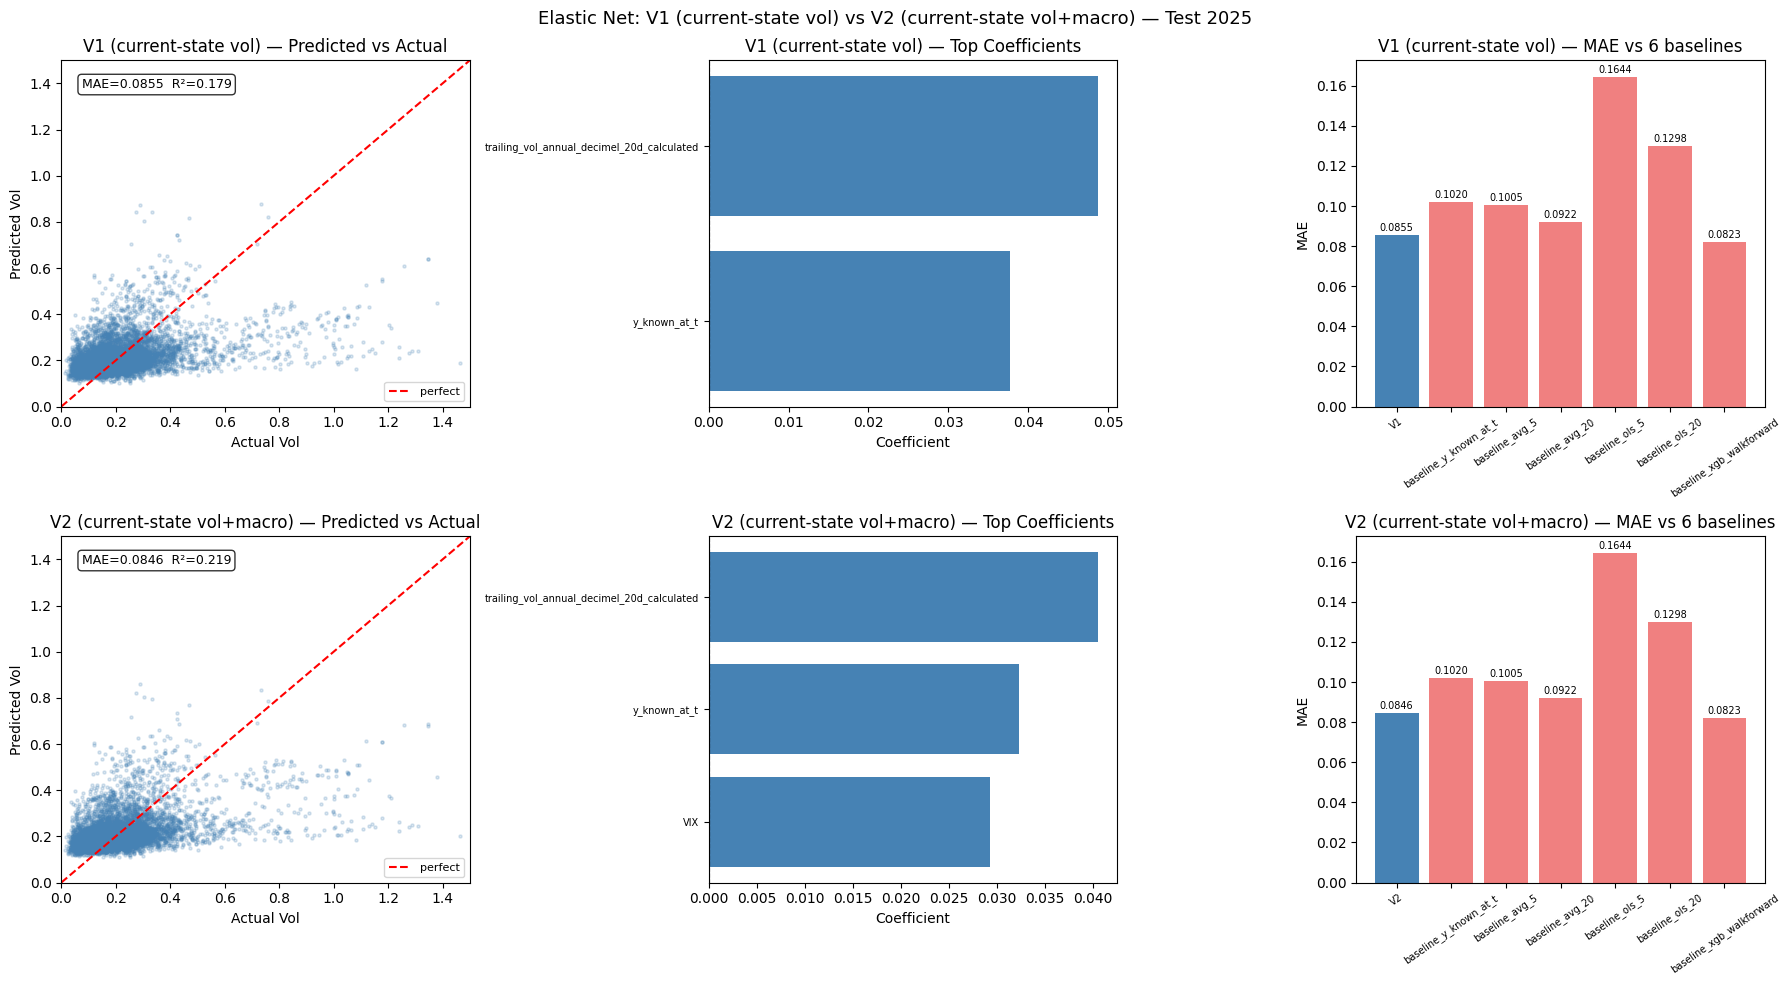

plot saved


In [13]:
# Cell 12 - Plots: V1 vs V2

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Elastic Net: V1 (current-state vol) vs V2 (current-state vol+macro) — Test 2025', fontsize=13)

for row_idx, (name, res) in enumerate(all_results.items()):
    y_test      = res['y_test']
    y_test_pred = res['y_test_pred']

    coef_df = pd.DataFrame({
        'feature': res['features'],
        'coef': res['model'].coef_
    }).sort_values('coef', key=abs, ascending=False)

    # col 0: predicted vs actual
    ax = axes[row_idx][0]
    ax.scatter(y_test, y_test_pred, alpha=0.2, s=5, color='steelblue')
    cap = min(max(y_test.max(), y_test_pred.max()) * 1.05, 1.5)
    ax.plot([0, cap], [0, cap], 'r--', linewidth=1.5, label='perfect')
    ax.set_xlabel('Actual Vol');  ax.set_ylabel('Predicted Vol')
    ax.set_title(f'{name} — Predicted vs Actual')
    ax.set_xlim(0, cap);  ax.set_ylim(0, cap)
    ax.legend(fontsize=8)
    ax.text(0.05, 0.92, f"MAE={res['m_test']['MAE']:.4f}  R²={res['m_test']['R2']:.3f}",
            transform=ax.transAxes, fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # col 1: top coefficients
    ax = axes[row_idx][1]
    top    = coef_df[coef_df['coef'] != 0].head(12)
    colors = ['tomato' if c < 0 else 'steelblue' for c in top['coef']]
    ax.barh(top['feature'], top['coef'], color=colors)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xlabel('Coefficient')
    ax.set_title(f'{name} — Top Coefficients')
    ax.tick_params(axis='y', labelsize=7)
    ax.invert_yaxis()

    # col 2: MAE vs baselines (shared rows)
    ax = axes[row_idx][2]
    model_names = [name.split(' ')[0]] + BASELINES
    maes        = [res['m_test']['MAE']]
    for col in BASELINES:
        b    = test_df[col].values
        keep = ~np.isnan(b)
        maes.append(mean_absolute_error(test_df[TARGET].values[keep], b[keep]))
    bar_colors = ['steelblue'] + ['lightcoral'] * len(BASELINES)
    bars = ax.bar(model_names, maes, color=bar_colors)
    ax.set_ylabel('MAE');  ax.set_title(f'{name} — MAE vs 6 baselines')
    ax.tick_params(axis='x', rotation=35, labelsize=7)
    for bar, val in zip(bars, maes):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('elastic_net_v1_v2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("plot saved")


**Comment on Output for Cell 12 - Plots: V1 vs V2**

These plots confirm the main modeling story visually.

V2 performs slightly better than V1, with lower MAE and higher R², but both models still underpredict the largest volatility spikes.

The coefficient plots show that V1 relies on the two current-state volatility features, while V2 keeps those same features and adds only VIX; the other macro variables are effectively removed by regularization.

The MAE comparison plots show that both Elastic Net versions outperform several weaker baselines, but the walk-forward XGBoost baseline remains the strongest benchmark.

## Cell 13 - Subgroup breakdown: market / sector / industry

**Purpose of this cell**

This cell evaluates how Elastic Net Version 1 and Version 2 perform across different ETF subgroup types:
*   market
*   sector
*   industry

Its purpose is to determine whether the relative performance of the two models is consistent across subgroup categories or whether one version performs better for some types of ETFs than for others.

**What this code is doing**

*   It first prints a table header showing the columns:
    *   Group
    *   Version
    *   n
    *   MAE
    *   RMSE
    *   R2
*   It then loops through the three subgroup labels stored in group_type:
    *   market
    *   sector
    *   industry
*   For each subgroup:
    *   it creates a boolean mask selecting only test rows in test_df that belong to that subgroup,
    *   it then loops through both model versions stored in all_results,
    *   extracts the true test target values (y_test) and model predictions (y_test_pred) for just that subgroup,
    *   computes subgroup-level:
        *   MAE
        *   RMSE
        *   R²
  *   prints the subgroup name, model version, number of rows, and the three metrics.
*   If a subgroup has no rows for a given model, the code skips it.
*   A blank line is printed after each subgroup block to make the output easier to read.

This cell provides a more detailed performance breakdown than the overall test summary by showing whether V1 and V2 behave differently for broad market ETFs, sector ETFs, and industry ETFs.

**Expected output**

If the cell runs correctly, it should:
*   print a subgroup comparison table.


In [14]:
# Cell 13 - Subgroup breakdown: market / sector / industry

print(f"\n{'Group':<12} {'Version':<22} {'n':>6}  {'MAE':>8}  {'RMSE':>8}  {'R2':>7}")
print('-' * 64)

for grp in ['market', 'sector', 'industry']:
    mask = test_df['group_type'].values == grp
    for name, res in all_results.items():
        sub_y    = res['y_test'][mask]
        sub_pred = res['y_test_pred'][mask]
        if len(sub_y) == 0:
            continue
        mae  = mean_absolute_error(sub_y, sub_pred)
        rmse = np.sqrt(mean_squared_error(sub_y, sub_pred))
        r2   = r2_score(sub_y, sub_pred)
        print(f"{grp:<12} {name:<22} {len(sub_y):>6,}  {mae:>8.4f}  {rmse:>8.4f}  {r2:>7.4f}")
    print()


Group        Version                     n       MAE      RMSE       R2
----------------------------------------------------------------
market       V1 (current-state vol)    245    0.0792    0.1264   0.1442
market       V2 (current-state vol+macro)    245    0.0802    0.1225   0.1973

sector       V1 (current-state vol)  3,185    0.0737    0.1148   0.1410
sector       V2 (current-state vol+macro)  3,185    0.0743    0.1123   0.1774

industry     V1 (current-state vol)  5,390    0.0927    0.1470   0.1367
industry     V2 (current-state vol+macro)  5,390    0.0910    0.1433   0.1796



**Comment on Output for Cell 13 - Subgroup breakdown: market / sector / industry**

This output shows that the benefit of adding current macro / market features varies across ETF subgroup types.

V2 improves R² and RMSE in market, sector, and industry ETFs, but it improves MAE only for industry ETFs while slightly worsening MAE for market and sector ETFs.

Because industry ETFs make up the largest subgroup and V2 improves across all metrics there, the industry improvement likely contributes meaningfully to V2’s overall advantage over V1.

## Cell 14 - Final summary

**Purpose of this cell**

This cell prints a final notebook-level summary of the Elastic Net analysis.

Its purpose is to gather the most important model results in one place, including V1 and V2 performance, the effect of adding current macro / market features, the lagged features excluded by design, the strongest baseline, each Elastic Net version's distance from that baseline, and the final date ranges and row counts used in the cleaned train, validation, and test splits.

**What this code is doing**

*   It prints a FINAL SUMMARY header.
*   It loops through the stored results for both model versions in all_results and prints, for each version:
    *   number of candidate features,
    *   number of retained features,
    *   number of zeroed features,
    *   best alpha,
    *   best l1_ratio,
    *   train MAE and train R²,
    *   test MAE and test R²,
    *   overfit gap (test MAE - train MAE).
*   It then computes the macro / market effect by comparing:
    *   V2 test MAE - V1 test MAE
    *   and converts that difference into a percentage relative to V1.
*   Based on the sign of that difference, it prints an interpretation of whether current macro / market features improved prediction performance.
*   It prints the full list of lagged features that were intentionally excluded from this notebook by design.
*   It prints:
    *   the best baseline on shared rows,
    *   the best baseline on full rows,
    *   V1's MAE gap versus the best shared-row baseline,
    *   V2's MAE gap versus the best shared-row baseline.
    *   Finally, it prints the cleaned split date ranges and row counts for:
    *   train_df
    *   val_df
    *   test_df
    *   test_full

This cell is the notebook's executive summary and is meant to make the final conclusions easy to read without scanning all prior cells.

**Expected output**

If the cell runs correctly, it should:
*   print a final summary table.

In [15]:
# Cell 14 - Final summary

print("\n" + "="*65)
print("FINAL SUMMARY")
print("="*65)

for name, res in all_results.items():
    print(f"\n{name}")
    print(f"  candidate features: {res['n_features']}")
    print(f"  retained:           {len(res['kept_features'])}")
    print(f"  zeroed:             {len(res['zeroed_features'])}")
    print(f"  best alpha:         {res['best_alpha']:.6f}")
    print(f"  best l1_ratio:      {res['best_l1ratio']:.2f}  (0=Ridge, 1=Lasso)")
    print(f"  train MAE:          {res['m_train']['MAE']:.4f}  R2={res['m_train']['R2']:.4f}")
    print(f"  test  MAE:          {res['m_test']['MAE']:.4f}  R2={res['m_test']['R2']:.4f}")
    print(f"  overfit gap:        {res['m_test']['MAE'] - res['m_train']['MAE']:+.4f}")

v1_mae = all_results['V1 (current-state vol)']['m_test']['MAE']
v2_mae = all_results['V2 (current-state vol+macro)']['m_test']['MAE']
delta  = v2_mae - v1_mae
pct    = delta / v1_mae * 100

print(f"\n{'='*65}")
print(f"Current macro / market impact (V2 - V1 test MAE):  {delta:+.4f}  ({pct:+.1f}%)")
if delta < 0:
    print("  V2 IMPROVES on V1  ->  current macro / market features add predictive value")
elif delta > 0:
    print("  V2 is WORSE than V1  ->  current volatility state alone is sufficient")
else:
    print("  No difference")

print("\nLagged features excluded from this notebook by design:")
for f in EXCLUDED_BY_DESIGN:
    print(f"  - {f}")

print(f"\nBest baseline (shared rows): {best_bl_shared['name']}  MAE={best_bl_shared['MAE']:.4f}")
print(f"Best baseline (full rows):   {best_bl_full['name']}  MAE={best_bl_full['MAE']:.4f}")
print(f"V1 vs best baseline: {v1_mae - best_bl_shared['MAE']:+.4f}")
print(f"V2 vs best baseline: {v2_mae - best_bl_shared['MAE']:+.4f}")

print(f"\nSplits (per methodology doc 2026-03-07):")
print(f"  train:     {train_df['date'].min().date()} to {train_df['date'].max().date()}  ({len(train_df):,} rows)")
print(f"  val:       {val_df['date'].min().date()} to {val_df['date'].max().date()}  ({len(val_df):,} rows)")
print(f"  test:      {test_df['date'].min().date()} to {test_df['date'].max().date()}  ({len(test_df):,} shared rows)")
print(f"  test_full: {test_full['date'].min().date()} to {test_full['date'].max().date()}  ({len(test_full):,} full rows)")
print("="*65)



FINAL SUMMARY

V1 (current-state vol)
  candidate features: 2
  retained:           2
  zeroed:             0
  best alpha:         0.019307
  best l1_ratio:      0.95  (0=Ridge, 1=Lasso)
  train MAE:          0.0802  R2=0.4331
  test  MAE:          0.0855  R2=0.1794
  overfit gap:        +0.0053

V2 (current-state vol+macro)
  candidate features: 8
  retained:           3
  zeroed:             5
  best alpha:         0.013257
  best l1_ratio:      0.90  (0=Ridge, 1=Lasso)
  train MAE:          0.0777  R2=0.4734
  test  MAE:          0.0846  R2=0.2188
  overfit gap:        +0.0069

Current macro / market impact (V2 - V1 test MAE):  -0.0008  (-1.0%)
  V2 IMPROVES on V1  ->  current macro / market features add predictive value

Lagged features excluded from this notebook by design:
  - VIX_lag1
  - VIX_lag20
  - VIX_lag5
  - trailing_vol_annual_decimel_20d_calculated_lag1
  - trailing_vol_annual_decimel_20d_calculated_lag20
  - trailing_vol_annual_decimel_20d_calculated_lag5
  - trailin

**Comment on Output for Cell 14 - Final summary**

This final summary shows that V2 is the stronger Elastic Net version, with slightly lower test MAE and higher test R² than V1.

The added current macro / market features improve performance by about 1.0% in MAE, although the gain is modest and comes with a slightly larger overfit gap.

Elastic Net keeps only 3 of V2's 8 candidate inputs, indicating that most added macro variables do not contribute enough signal after regularization.

Both Elastic Net versions remain behind the walk-forward XGBoost baseline on MAE, but V2 is closer to that benchmark.

